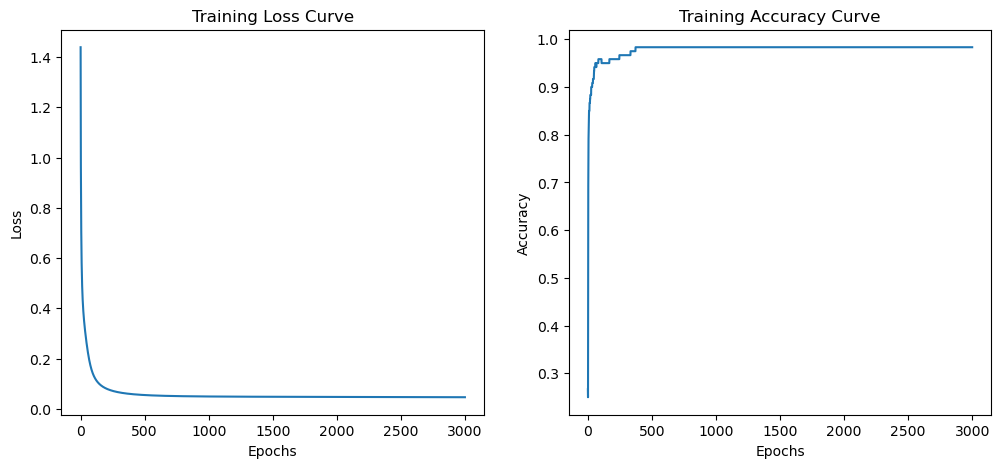

Test Accuracy: 1.0


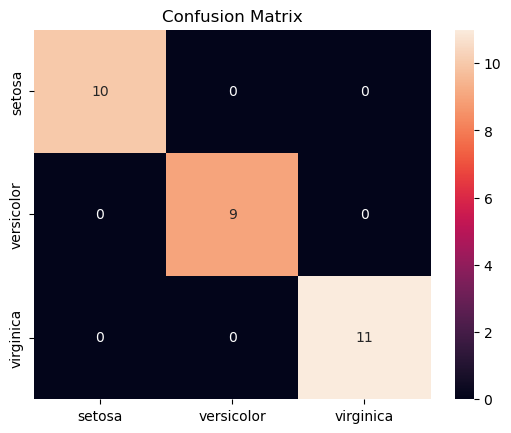

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30

Sample 1: Predicted = versicolor, Actual = versicolor
Sample 2: Predicted = setosa, Actual = setosa
Sample 3: Predicted = virginica, Actual = virginica
Sample 4: Predicted = versicolor, Actual = versicolor
Sample 5: Predicted = versicolor, Actual = versicolor


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
iris = load_iris()
X = iris.data
y = iris.target.reshape(-1, 1)
class_names = iris.target_names
y = pd.get_dummies(y.flatten()).values
scaler = StandardScaler()
X = scaler.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size=0.2, random_state=42
)
input_size = 4
hidden_size = 6
output_size = 3
learning_rate = 0.01
epochs = 3000
np.random.seed(10)
W1 = np.random.randn(input_size, hidden_size)
b1 = np.zeros((1, hidden_size))
W2 = np.random.randn(hidden_size, output_size)
b2 = np.zeros((1, output_size))
def sigmoid(x):
    return 1 / (1 + np.exp(-x))
def sigmoid_derivative(a):
    return a * (1 - a)
def softmax(x):
    exp_x = np.exp(x - np.max(x, axis=1, keepdims=True))
    return exp_x / np.sum(exp_x, axis=1, keepdims=True)
def cross_entropy(y_true, y_pred):
    return -np.mean(np.sum(y_true * np.log(y_pred + 1e-9), axis=1))
loss_history = []
accuracy_history = []
for epoch in range(epochs):
    Z1 = np.dot(X_train, W1) + b1
    A1 = sigmoid(Z1)
    Z2 = np.dot(A1, W2) + b2
    A2 = softmax(Z2)
    loss = cross_entropy(y_train, A2)
    predictions = np.argmax(A2, axis=1)
    true_labels = np.argmax(y_train, axis=1)
    accuracy = np.mean(predictions == true_labels)
    loss_history.append(loss)
    accuracy_history.append(accuracy)
    error = A2 - y_train
    dW2 = np.dot(A1.T, error)
    db2 = np.sum(error, axis=0, keepdims=True)
    d_hidden = np.dot(error, W2.T) * sigmoid_derivative(A1)
    dW1 = np.dot(X_train.T, d_hidden)
    db1 = np.sum(d_hidden, axis=0, keepdims=True)
    W2 -= learning_rate * dW2
    b2 -= learning_rate * db2
    W1 -= learning_rate * dW1
    b1 -= learning_rate * db1
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(loss_history)
plt.title("Training Loss Curve")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.subplot(1,2,2)
plt.plot(accuracy_history)
plt.title("Training Accuracy Curve")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.show()
Z1 = np.dot(X_test, W1) + b1
A1 = sigmoid(Z1)
Z2 = np.dot(A1, W2) + b2
A2 = softmax(Z2)
test_predictions = np.argmax(A2, axis=1)
test_true = np.argmax(y_test, axis=1)
print("Test Accuracy:", np.mean(test_predictions == test_true))
cm = confusion_matrix(test_true, test_predictions)
sns.heatmap(cm, annot=True, fmt="d",
xticklabels=class_names,
yticklabels=class_names)
plt.title("Confusion Matrix")
plt.show()
print(classification_report(test_true, test_predictions,
target_names=class_names))
for i in range(5):
    print(f"Sample {i+1}: Predicted = {class_names[test_predictions[i]]}, "
    f"Actual = {class_names[test_true[i]]}")